## Iterative Methods for Linear Systems - (Chapter 9, McClarren)

We've been looking at direct methods so far.  They are direct because the amount of work required to get the answer to the linear system is fixed based on the size of the problem.  The computational cost also doesn't really depend on the details of the matrix problem at all (except if you include pivoting...).

There are other techniques that are iterative in nature - guess at the solution and refine that guess until we are "close enough".  Most of the methods in this family require diagonal dominance for them to work.  

## Diagonal dominance 

Diagonal dominance means that for each row $i$ in the matrix $A$ of size $I$ by $I$,

$$ \left| A_{ii} \right| > \sum\limits_{j=1,j\ne i} ^{I} A_{ij}, \qquad i=1 \cdots I $$

In other words, the diagonal is larger than the sum of the magnitudes of the off diagonal elements of each row. 

## Jacobi Iteration
<img src="Uploaded Media/Jacobi0.png">

<img src="Uploaded Media/Jacobi1.png">

<img src="Uploaded Media/Jacobi2.png">

Take the system $A x= b$ and split it into two parts: one that acts on the new guess, and one that acts on the old guess:

$$ A_{ii} x_i^{(l+1)} = b_i - \sum\limits_{j=1,j\ne i} ^{I} A_{ij} x_j^{(l)} , \qquad i=1 \cdots I, l=0 \cdots $$

$$ x_i^{(l+1)} = \frac{1}{A_{ii}}(b_i - \sum\limits_{j=1,j\ne i} ^{I} A_{ij} x_j^{(l)}) , \qquad i=1 \cdots I, l=0 \cdots $$


When do we stop?  We'll stop when either the change in $x$ is small, 
the residual is small, or a certian number of iterations is met. 

$$\frac{|| x^{(l+1)} - x^{(l)}||_2}{|| x^{(l+1)}||_2} < \varepsilon $$

where $\varepsilon$ is a user defined tolerance, and the "2-norm" is 

$$ || y||_2 = \sqrt{\sum\limits_{i=1}^I y_i^2} $$

<div class="alert alert-block alert-info">
<h2> <b>Think:</b> What does the 2-norm tell us?  </h2>
</div>





Ok, let's start with a system. We have a defined $A$, and $b$. Let's assume some initial guess for $x$. 

In [10]:
import numpy as np
A = np.array([(2.5,-1,0,0),(-1,2.5,-1,0),(0,-1,2.5,-1),(0,0,-1,2.5)])
print("Our matrix is\n",A)
b = np.array([1.0,1,1,1])
x = np.array([0,0.5,0.5,0])
print("Our RHS is",b)
print("The initial guess is",x)

Our matrix is
 [[ 2.5 -1.   0.   0. ]
 [-1.   2.5 -1.   0. ]
 [ 0.  -1.   2.5 -1. ]
 [ 0.   0.  -1.   2.5]]
Our RHS is [1. 1. 1. 1.]
The initial guess is [0.  0.5 0.5 0. ]


$$ x_i^{(l+1)} = \frac{1}{A_{ii}}(b_i - \sum\limits_{j=1,j\ne i} ^{I} A_{ij} x_j^{(l)}) , \qquad i=1 \cdots I

In [11]:
#first Jacobi iteration
x_new = np.zeros(4)
for row in range(4):  #for x1, x2, x3, x4
    x_new[row] = b[row]  #the new x_i = b_i
    for column in range(4): 
        if column != row: # j /= i
            x_new[row] -= A[row,column]*x[column]  # x_i = b_i - A_ij*x_j 
    # important to put this at the right spot in the indention...
    x_new[row] /= A[row,row]  # x_i = x_i/A_ii
relative_change = np.linalg.norm(x_new-x)/np.linalg.norm(x_new)
print("New guess is",x_new)
print("Norm of change is",relative_change)

New guess is [0.6 0.6 0.6 0.6]
Norm of change is 0.7168604389202189


Let's do another iteration..... 

In [ ]:
x = x_new.copy() #replace old value
x_new *= 0 #reset x_new
for row in range(4):
    x_new[row] = b[row]
    for column in range(4):
        if column != row:
            x_new[row] -= A[row,column]*x[column]
    x_new[row] /= A[row,row]
#check relative difference
relative_change = np.linalg.norm(x_new-x)/np.linalg.norm(x_new)
print("New guess is",x_new)
print("Norm of change is",relative_change)

New guess is [0.64 0.88 0.88 0.64]
Norm of change is 0.2599376224550183


Ok. We have an update for our $x$ vector. Our difference is going down each iteration. We can keep going... Let's do one more iteration...

In [13]:
#Third Jacobi Iteration
x = x_new.copy() #replace old value
x_new *= 0 #reset x_new
for row in range(4):
    x_new[row] = b[row]
    for column in range(4):
        if column != row:
            x_new[row] -= A[row,column]*x[column]
    x_new[row] /= A[row,row]
#check difference
relative_change = np.linalg.norm(x_new-x)/np.linalg.norm(x_new)
print("New guess is",x_new)
print("Norm of change is",relative_change)

New guess is [0.752 1.008 1.008 0.752]
Norm of change is 0.1352431475798435


This is a good direction. We can keep iterating like this, but it would be good to write a general form that we can use in real applications. Let's first look at the algorithm for the method.... 

Here is a nicely formatted way of expressing this algorithm using LaTeX's `algorithm` environment:

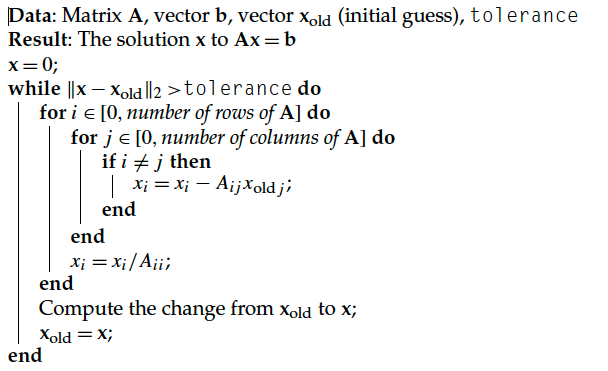

Now let's write a general solver for this so we don't have to go through and execute it for each iteration. 

In [14]:
def JacobiSolve(A,b,x0=np.array([]),tol=1.0e-6,
                max_iterations=100,LOUD=False,):
    '''Solve a linear system by Jacobi iteration.
    Note: system must be diagonally dominant
    Args:
        A: N by N array
        b: array of length N
        x0: initial guess (if none given will be random)
        tol: Relative L2 norm tolerance for convergence
        max_iterations: maximum number of iterations
    Returns:
        The approximate solution to the linear system
    '''
    [Nrow, Ncol] = A.shape
    assert Nrow == Ncol
    N = Nrow
    converged = False
    iteration = 1
    
    if (x0.size==0):
        #random initial guess
        x0 = np.random.rand(N)
    x = x0.copy()
    
    while not(converged):
        #replace old value
        x0 = x.copy()
        for row in range(N):
            x[row] = b[row]
            for column in range(N):
                if column != row:
                    x[row] -= A[row,column]*x0[column]
            x[row] /= A[row,row]
        relative_change = np.linalg.norm(x-x0)/np.linalg.norm(x)
        if (LOUD):
            print("Iteration",iteration,
                  ": Relative Change =",relative_change)
        if (relative_change < tol) or (iteration >= max_iterations):
            converged = True
        iteration += 1
    return x

Let's use this function in an example: a 4x4 matrix...

In [15]:
A = np.array([(2.3,-1,0,0),(-1,2.3,-1,0),(0,-1,2.3,-1),(0,0,-1,2.3)])
print("Our matrix is\n",A)
b = np.array([1.0,1,1,1])
x = JacobiSolve(A,b,tol=1.0e-6,LOUD=True)
print(x)

Our matrix is
 [[ 2.3 -1.   0.   0. ]
 [-1.   2.3 -1.   0. ]
 [ 0.  -1.   2.3 -1. ]
 [ 0.   0.  -1.   2.3]]
Iteration 1 : Relative Change = 0.5618107711397273
Iteration 2 : Relative Change = 0.2372220513914684
Iteration 3 : Relative Change = 0.13763067714704355
Iteration 4 : Relative Change = 0.08781790816373139
Iteration 5 : Relative Change = 0.05821596455223394
Iteration 6 : Relative Change = 0.03937761894108241
Iteration 7 : Relative Change = 0.02697405884113288
Iteration 8 : Relative Change = 0.01863182081885691
Iteration 9 : Relative Change = 0.012942216347883487
Iteration 10 : Relative Change = 0.009024765449229671
Iteration 11 : Relative Change = 0.006309858859776228
Iteration 12 : Relative Change = 0.004419840761565606
Iteration 13 : Relative Change = 0.0030999430082252074
Iteration 14 : Relative Change = 0.002176167831487802
Iteration 15 : Relative Change = 0.0015286404484406218
Iteration 16 : Relative Change = 0.001074263141839304
Iteration 17 : Relative Change = 0.0007551809

Ok, we have an answer for x now! Great. Let's put it in and compare to what we know the answer is.... 

In [7]:
#Check the answer
print("Ax =",np.dot(A,x))
print("b =",b)

Ax = [0.99999801 0.99999776 0.99999678 0.99999862]
b = [1. 1. 1. 1.]


Great start!

We can do something bigger, too!

In [35]:
N = 100
A = np.zeros((N,N))
b = np.ones(N)
#same structure as before
for i in range(N):
    A[i,i] = 2.5
    if (i>0):
        A[i,i-1] = -1
    if (i < N-1):
        A[i,i+1] = -1
x100 = JacobiSolve(A,b,tol=1.0e-6,LOUD=True)
print(x100)

Iteration 1 : Relative Change = 0.5427946691137872
Iteration 2 : Relative Change = 0.29928033272550636
Iteration 3 : Relative Change = 0.19326942823288099
Iteration 4 : Relative Change = 0.13356651193717817
Iteration 5 : Relative Change = 0.09607161882485435
Iteration 6 : Relative Change = 0.07092858419528202
Iteration 7 : Relative Change = 0.053322122269500276
Iteration 8 : Relative Change = 0.04061347042337789
Iteration 9 : Relative Change = 0.031235756240808273
Iteration 10 : Relative Change = 0.02420106924687122
Iteration 11 : Relative Change = 0.018857567378639254
Iteration 12 : Relative Change = 0.014759266196293438
Iteration 13 : Relative Change = 0.011592216420902239
Iteration 14 : Relative Change = 0.00913022351084961
Iteration 15 : Relative Change = 0.007207276308510313
Iteration 16 : Relative Change = 0.005699672088682766
Iteration 17 : Relative Change = 0.004514104585704307
Iteration 18 : Relative Change = 0.0035794880902082138
Iteration 19 : Relative Change = 0.00284122696

## Convergence of the Jacobi Method...

Let's look at a 2x2 and make a plot of how the soution is changing with each iteration.  Here's the example problem:

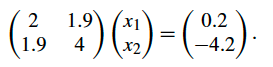

The answer is $x_1 = 2$ and $x_2 = -2$.  We'll start with an initial guess of $x^{(0)} = (-1,0.5)^{T}$.

In [1]:
import numpy as np

In [7]:
def JacobiSolve(A,b,x0=np.array([]),tol=1.0e-6,
                max_iterations=100,LOUD=False,):
    '''Solve a linear system by Jacobi iteration.
    Note: system must be diagonally dominant
    Args:
        A: N by N array
        b: array of length N
        x0: initial guess (if none given will be random)
        tol: Relative L2 norm tolerance for convergence
        max_iterations: maximum number of iterations
    Returns:
        The approximate solution to the linear system
    '''
    [Nrow, Ncol] = A.shape
    assert Nrow == Ncol
    N = Nrow
    converged = False
    iteration = 1
    #create a matrix to store solutions from all iterations
    x_sols=np.empty((0,N))
    
    if (x0.size==0):
        #random initial guess
        x0 = np.random.rand(N)
    
    #new guess
    x = x0.copy()

    #put the initial guess in the solution matrix
    x_sols = x.copy()
    
    while not(converged):
        #replace old value
        x0 = x.copy()
        for row in range(N):
            x[row] = b[row]
            for column in range(N):
                if column != row:
                    x[row] -= A[row,column]*x0[column]
            x[row] /= A[row,row]
        relative_change = np.linalg.norm(x-x0)/np.linalg.norm(x)
        if (LOUD):
            print("Iteration",iteration,
                  ": Relative Change =",relative_change)
        if (relative_change < tol) or (iteration >= max_iterations):
            converged = True
        iteration += 1
        #put the new guess into the solution matrix
        x_sols = np.vstack((x_sols,x))
    #return x    
    return x_sols #return the matrix that contains all guesses rather than the final solution alone

In [4]:
x_old = [-1.,  2.]
x_new = [-1.8,   -0.575]

print("result of np.append\n", np.append(x_old,x_new))

print("result of np.vstack\n", np.vstack((x_old,x_new)))

result of np.append
 [-1.     2.    -1.8   -0.575]
result of np.vstack
 [[-1.     2.   ]
 [-1.8   -0.575]]


Iteration 1 : Relative Change = 1.811399212971375
Iteration 2 : Relative Change = 0.9799663546422328
Iteration 3 : Relative Change = 0.3412938035999139
Iteration 4 : Relative Change = 0.2355094140896661
Iteration 5 : Relative Change = 0.11079397238772494
Iteration 6 : Relative Change = 0.08763130519793444
Iteration 7 : Relative Change = 0.044247691773961546
Iteration 8 : Relative Change = 0.03663887422945471
Iteration 9 : Relative Change = 0.018975536588649
Iteration 10 : Relative Change = 0.016002572898404295
Iteration 11 : Relative Change = 0.008374627720662593
Iteration 12 : Relative Change = 0.007118034015000156
Iteration 13 : Relative Change = 0.0037419223714752065
Iteration 14 : Relative Change = 0.0031914440840796815
Iteration 15 : Relative Change = 0.0016810860815100624
Iteration 16 : Relative Change = 0.0014359894465285415
Iteration 17 : Relative Change = 0.0007570811816659063
Iteration 18 : Relative Change = 0.0006471487636253546
Iteration 19 : Relative Change = 0.00034132648

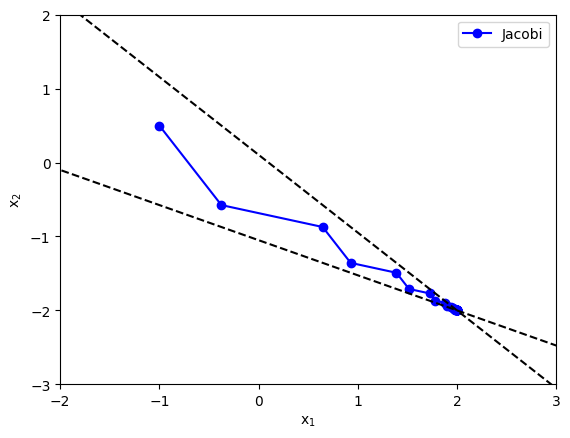

In [17]:
import matplotlib.pyplot as plt 
import numpy as np
A = np.array([(2,1.9),(1.9,4)])
solution = np.ones(2)*2
solution[1] = -2
b = np.dot(A,solution)
x0 = np.array([-1,0.5])
solutions = JacobiSolve(A,b,x0=x0, LOUD=True)
plt.plot(solutions[:,0],solutions[:,1],'bo-', label='Jacobi')
xpoint = np.linspace(-5,5,100)
line1 = lambda x: (0.2 - 2*x)/1.9
line2 = lambda x: (-4.2 - 1.9*x)/4
plt.plot(xpoint,line1(xpoint),'--', color = 'black')
plt.plot(xpoint,line2(xpoint),'--', color = 'black')
plt.axis([-2,3,-3,2])
plt.legend(); plt.xlabel('x$_1$'); plt.ylabel('x$_2$')
plt.show()

## Time to Solution - Jacobi

We can do the same computational efficiency experiment that we did previously with Gaussian Elimination with Jacobi's method.  

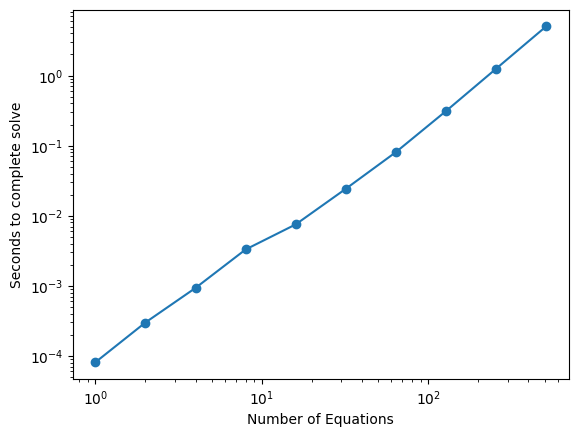

Approximate growth rate is n^ 2.009085417760407


In [32]:
import time
num_tests = 10
I = 2**np.arange(num_tests)
times = np.zeros(num_tests)
for test in range(num_tests):
    N = I[test]
    A = np.zeros((N,N))
    b = np.ones(N)
    #same structure as before
    for i in range(N):
        A[i,i] = 2.5
        if (i>0):
            A[i,i-1] = -1
        if (i < N-1):
            A[i,i+1] = -1
    start = time.time()
    x = JacobiSolve(A,b)
    end = time.time()
    times[test] = end-start
plt.loglog(I,times,'o-')
plt.xlabel("Number of Equations")
plt.ylabel("Seconds to complete solve")
plt.show()
print("Approximate growth rate is n^",
      (np.log(times[test])-np.log(times[test-1]))/
      (np.log(I[test])-np.log(I[test-1])))

So Jacobi goes as $O(N^2)$, and Gaussian Elimination goes as $O(N^3)$, so at some point Jacobi will be significantly faster than GE.  But, remember Jacobi only works for diagonally dominant linear systems.

We also can't guarantee the number of iterations it will take to converge Jacobi, but we have a definite prescription for the amount of work it takes for GE.  


Also, in these estimates of timing, what we really have are $C_1 N^2$ and $C_2 N^3$, and the size of the two constants will play a role in which one is faster. 

For example, $$ n^3 < 1000 n^2 \quad \text{for } n < 1000. $$


## A Faster Jacobi Method...


With NumPy we can make a simpler Jacobi iteration that should also be faster by removing
the inner two for loops. We can do this by using the fact that we can represent the Jacobi
method using matrix-vector products, vector addition, and scalar division. To do this we
notice that the inner update of a Jacobi iteration can be written as


$$ x_i^{(l+1)} = \frac{1}{A_{ii}} \left( b_i - \sum\limits_{j=1,j\ne i} ^{I} A_{ij} x_i^{(l)}  \right), \qquad i=1 \cdots I, l=0 \cdots $$

but we could add and subtract $A_{ii} x_i^{(l)}$ inside the sum to instead write:

$$ x_i^{(l+1)} = \frac{1}{A_{ii}} \left( b_i - \textbf{a}_{i} \cdot \textbf{x}^{(l)} + A_{ii} x_i^{(l)} \right), \qquad i=1 \cdots I, l=0 \cdots $$

where $\textbf{a}_{i}$ is the $i$-th row of matrix $A$, and $\textbf{x}$ is the solution vector.  

Or, we can represent this in terms of matrix vector products via:

$$ \textbf{x}^{(l+1)} = \frac{1}{\texttt{Diag}(A)} \left(\textbf{b} - \textbf{A} \cdot \textbf{x}^{(l)} + \texttt{Diag}(A) \times \textbf{x}^{(l)} \right) $$



`Diag(A)` means the vector of diagonal entries of an $N \times N$ matrix:

$$
\mathrm{Diag}(A) =
\begin{bmatrix}
a_{11} \\
a_{22} \\
\vdots \\
a_{NN}
\end{bmatrix}
$$



NOTE: the textbook is incorrect here:
$$ \textbf{x}^{(l+1)} = \frac{1}{\texttt{Diag}(A)} \left(\textbf{b} - \textbf{A} \cdot \textbf{x}^{(l)} + \texttt{Diag}(A) \cdot \textbf{x}^{(l)} \right) $$






We can rewrite the algorithm now, without for loops...

In [6]:
def JacobiSolve_Short(A,b,x0=np.array([]),tol=1.0e-6, max_iterations=100,LOUD=False):
    '''Solve a linear system by Jacobi iteration.
    This implementation removes the for loops to make it faster
    Note: system must be diagonally dominant
    Args:
        A: N by N array
        b: array of length N
        tol: Relative L2 norm tolerance for convergence
        max_iterations: maximum number of iterations
    Returns:
        The approximate solution to the linear system
    '''
    [Nrow, Ncol] = A.shape
    assert Nrow == Ncol
    N = Nrow
    converged = False
    iteration = 1
    if (x0.size==0):
        #random initial guess
        x0 = np.random.rand(N)
    x = x0.copy()
    while not(converged):
        x0 = x.copy() #replace old value
        #update is (b - whole row * x + diagonal part * x)/diagonal
        x = (b - np.dot(A,x0)+ A.diagonal()*x0)/A.diagonal()
        relative_change = np.linalg.norm(x-x0)/np.linalg.norm(x)
        if (LOUD):
            print("Iteration", iteration,
                  ": Relative Change =",relative_change)
        if (relative_change < tol) or (iteration >= max_iterations):
            converged = True
        iteration += 1
    return x

In [36]:
N = 100
A = np.zeros((N,N))
b = np.ones(N)
#same structure as before
for i in range(N):
    A[i,i] = 2.5
    if (i>0):
        A[i,i-1] = -1
    if (i < N-1):
        A[i,i+1] = -1
x100_Short = JacobiSolve_Short(A,b,tol=1.0e-6,LOUD=True)
# recall when we implemented Jacobi earlier we got a big matrix and 
# named it x100. 
print(x100_Short-x100)

Iteration 1 : Relative Change = 0.5653546038822729
Iteration 2 : Relative Change = 0.2941283753938451
Iteration 3 : Relative Change = 0.18837396378235233
Iteration 4 : Relative Change = 0.1301061090946322
Iteration 5 : Relative Change = 0.09372454861618294
Iteration 6 : Relative Change = 0.06937014714436467
Iteration 7 : Relative Change = 0.052309341436237534
Iteration 8 : Relative Change = 0.03997522289627492
Iteration 9 : Relative Change = 0.030851434507255367
Iteration 10 : Relative Change = 0.02398671512076133
Iteration 11 : Relative Change = 0.018754816518378875
Iteration 12 : Relative Change = 0.014727943195567606
Iteration 13 : Relative Change = 0.011604867591018338
Iteration 14 : Relative Change = 0.00916833582325647
Iteration 15 : Relative Change = 0.007258559957419042
Iteration 16 : Relative Change = 0.005756155269825912
Iteration 17 : Relative Change = 0.004570782688780628
Iteration 18 : Relative Change = 0.003633374295871537
Iteration 19 : Relative Change = 0.00289068682062

These are pretty close! But is it faster?
  
You'll need to take this on faith at this point (or prove it to yourself...), but the *fast Jacobi* is in fact, faster.

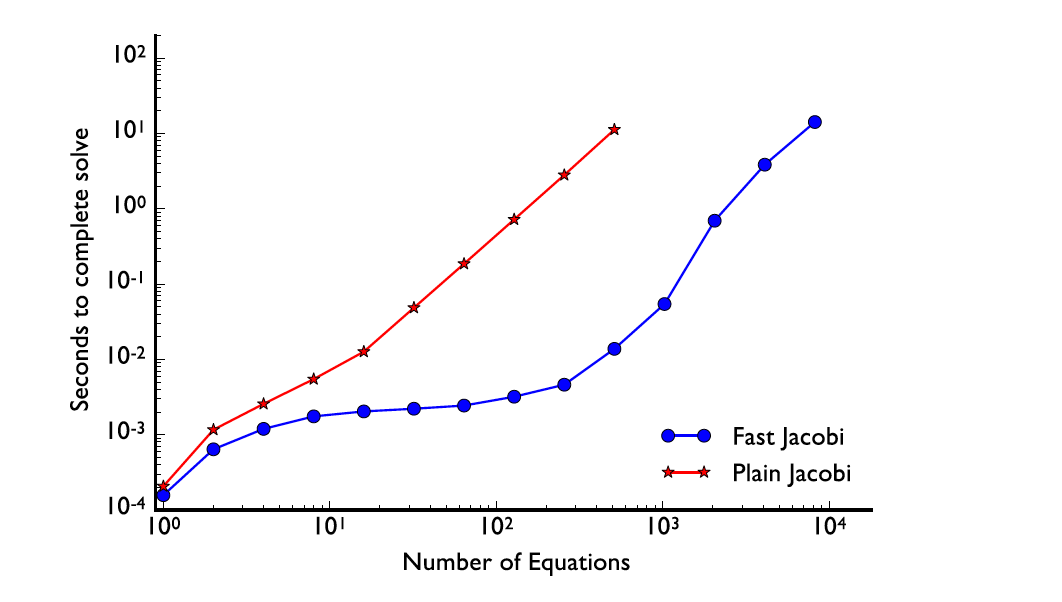

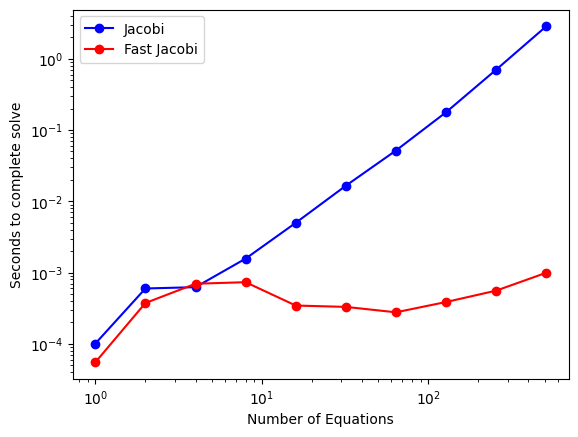

Approximate growth rate is n^ 2.021903436436078


In [12]:
import time
import matplotlib.pyplot as plt
num_tests = 10
I = 2**np.arange(num_tests)
times_j = np.zeros(num_tests)
times_jf = np.zeros(num_tests)
for test in range(num_tests):
    N = I[test]
    A = np.zeros((N,N))
    b = np.ones(N)
    #same structure as before
    for i in range(N):
        A[i,i] = 2.5
        if (i>0):
            A[i,i-1] = -1
        if (i < N-1):
            A[i,i+1] = -1
    start = time.time()
    x = JacobiSolve(A,b)
    end = time.time()
    times_j[test] = end-start

    start = time.time()
    x = JacobiSolve_Short(A,b)
    end = time.time()
    times_jf[test] = end-start


plt.loglog(I,times_j,'bo-',label='Jacobi')
plt.loglog(I,times_jf,'ro-',label='Fast Jacobi')
plt.xlabel("Number of Equations")
plt.ylabel("Seconds to complete solve")
plt.legend()
plt.show()
print("Approximate growth rate is n^",
      (np.log(times_j[test])-np.log(times_j[test-1]))/
      (np.log(I[test])-np.log(I[test-1])))

### Gauss Seidel 

The simplest way to understand Gauss Seidel is that, as soon as there is a new updated element of $x$ computed, we use it, rather than always using *old* information in the iteration.  In math, this looks like:

$$ x_i^{(l+1)} = \frac{1}{A_{ii}} \left( b_i - \sum\limits_{j=1}^{i-1} A_{ij} x_i^{(l+1)} - \sum\limits_{j=i+1}^{I} A_{ij} x_i^{(l)}  \right), \qquad i=1 \cdots I, l=0 \cdots $$

In [40]:
def Gauss_Seidel_Solve(A,b,tol=1.0e-6,max_iterations=100,LOUD=False):
    """Solve a linear system by Gauss-Seidel iteration.
    Note: system must be diagonally dominant
    Args:
        A: N by N array
        b: array of length N
        tol: Relative L2 norm tolerance for convergence
        max_iterations: maximum number of iterations
    Returns:
        The approximate solution to the linear system
    """
    [Nrow, Ncol] = A.shape
    assert Nrow == Ncol
    N = Nrow
    converged = False
    iteration = 1
    x = np.random.rand(N) #random initial guess 
    x_new = np.zeros(N)
    
    while not(converged):
        x = x_new.copy() #replace old value
        for row in range(N):
            x_new[row] = b[row]
            for column in range(N):
                if column != row:
                    '''previously
                    x_new[row] -= A[row,column]*x_old[column]
                    #only change from before is that I use x_new in the update '''
                    x_new[row] -= A[row,column]*x_new[column]
            x_new[row] /= A[row,row]
        relative_change = np.linalg.norm(x_new-x)/np.linalg.norm(x_new)
        if (LOUD):
            print("Iteration",iteration,": Relative Change =",relative_change)
        if (relative_change < tol) or (iteration >= max_iterations):
            converged = True
        iteration += 1
    return x_new

In [41]:
import numpy as np
N = 100
A = np.zeros((N,N))
b = np.ones(N)
#same structure as before
for i in range(N):
    A[i,i] = 2.5
    if (i>0):
        A[i,i-1] = -1
    if (i < N-1):
        A[i,i+1] = -1
x100_GS = Gauss_Seidel_Solve(A,b,LOUD=True)
print(x100_GS)

Iteration 1 : Relative Change = 1.0
Iteration 2 : Relative Change = 0.3986603038884974
Iteration 3 : Relative Change = 0.20923688836146034
Iteration 4 : Relative Change = 0.1220054774291872
Iteration 5 : Relative Change = 0.07497774238647387
Iteration 6 : Relative Change = 0.04745863298732882
Iteration 7 : Relative Change = 0.03057708116415138
Iteration 8 : Relative Change = 0.019919379331953688
Iteration 9 : Relative Change = 0.013068316196330539
Iteration 10 : Relative Change = 0.008612920601712593
Iteration 11 : Relative Change = 0.005693553762661967
Iteration 12 : Relative Change = 0.0037711713183731905
Iteration 13 : Relative Change = 0.002501152663253116
Iteration 14 : Relative Change = 0.0016602953098224403
Iteration 15 : Relative Change = 0.0011027729868139725
Iteration 16 : Relative Change = 0.0007327556220198192
Iteration 17 : Relative Change = 0.00048702235373140505
Iteration 18 : Relative Change = 0.00032375625133220003
Iteration 19 : Relative Change = 0.0002152494291417719

So, for this matrix, Gauss Seidel took 33 iterations, and Jacobi took 56 iterations.  Not quite a factor of 2 improvement, but certainly better!

If we observe the convergence behavior from Gauss Seidel using the 2x2 considered earlier, we see:

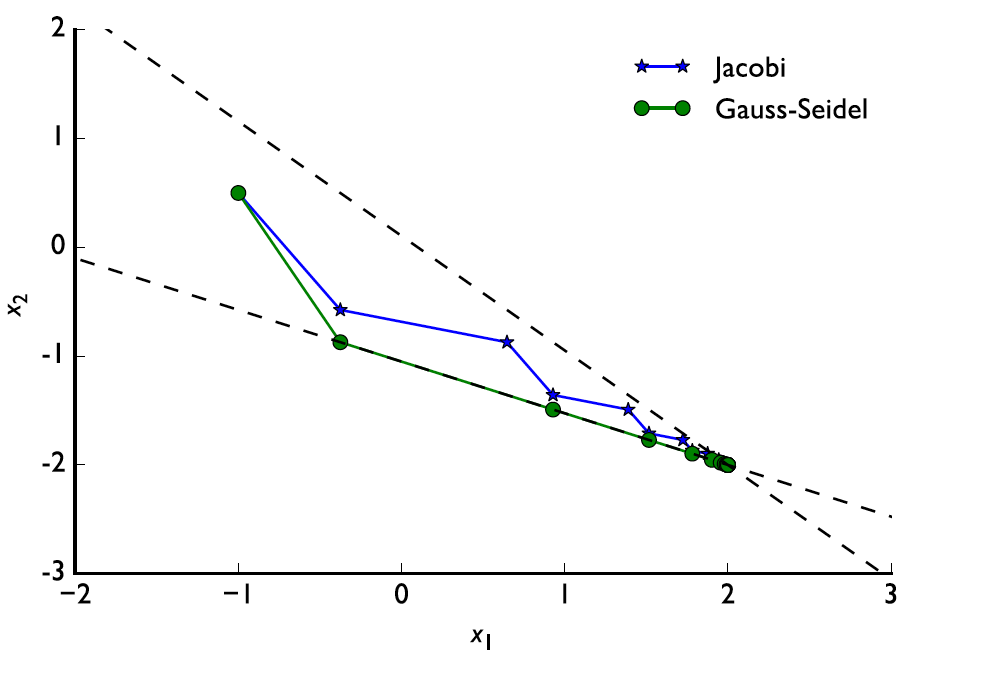

And the timing of Gauss Seidel looks like this, in comparison with Jacobi:

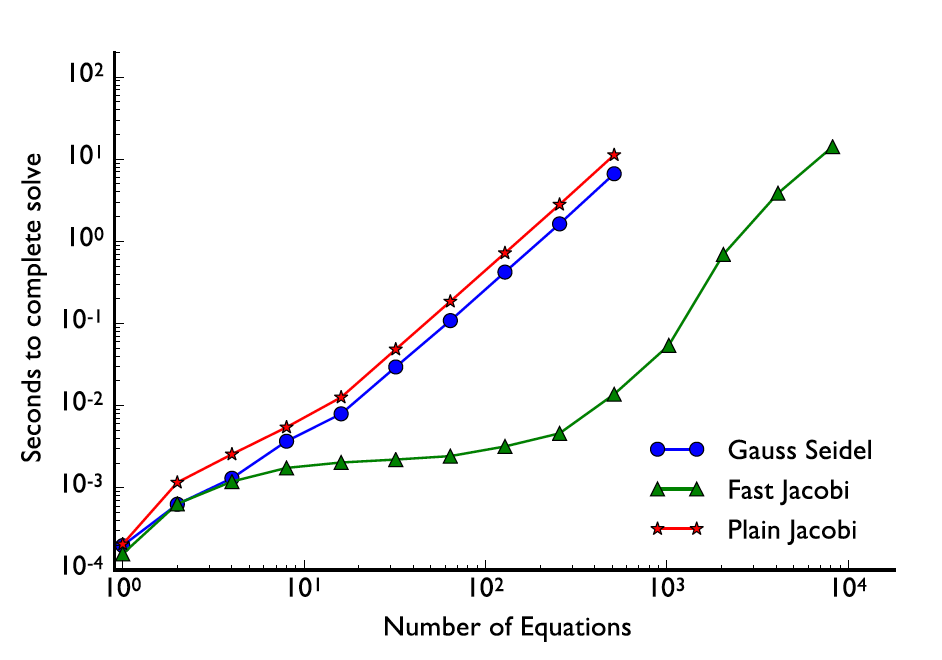

A couple other things to mention:
1. While there are fewer iterations in Gauss Seidel, it is not as computationally cheap as Fast Jacobi.
2. We can't make a Fast Gauss Seidel because done in the same fast manner as Jacobi because in each equation of Jacibi is independent of another -- the 10th x does not depend on the 9th. In gauss seidel this isn't the case. 

There are three other concepts that are covered in this chapter, and we are going to leave them be: Successive Over Relaxation (SOR), Conjugate Gradient (CG), and algorithms that rely on tridiagonal or banded matrix forms.  